# Permutación y guiado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from numpy.linalg import norm
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings("ignore")

# 1. Importación de elementos

In [2]:
def visualizar_RS(df_sel):
    y_test = df_sel['SSPL']
    y_pred = df_sel['SSPL_pred']

    # Asume que ya tienes: y_test (Series), y_pred (array-like), pred_obj (float)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

    plt.xlabel("SSPL real")
    plt.ylabel("SSPL predicho")
    plt.title("Predicción vs Realidad")
    plt.tight_layout()
    plt.show()

# 2. Carga de datos y revisión básica de calidad

Para la implementación de FUCO en primer lugar es necesario realizar la carga del conjunto de datos. En este caso, se hace uso del conjunto de datos *AirfoilSelfNoise.csv* l cual es un conjunto de datos de la NASA obtenido a partir de una serie de pruebas aerodinámicas y acústicas de secciones de álabes aerodinámicos bidimensionales y tridimensionales, realizadas en un túnel de viento anecoico.  Es por esto que se pasa a realizar la carga del conjuto de datos en el entorno:

In [3]:
# Se realiza la carga de los datos
df = pd.read_csv("AirfoilSelfNoise.csv", sep=',')

# 3. Modelado

Como paso previo a la implementación de FUCO, es necesario tener un modelo de regresión en el entorno. En esta implementación se ha obtado por entrenar un modelo de regresión lineal que se encargue de predección la variable **SSPL** a partir del resto de variables existentes en el conjunto de datos. Para esta implementación se ha decidido no optimizar mediante hiperparámetros el modelo ya que esta implementación no busca rendimiento sino la capacidad de mostrar la implementación y funcionamiento del framework. Se pasa a realizar el entrenamiento del modelo:

Intercepto: 132.5315974058017

Coeficientes:
f              -0.001272
alpha          -0.405660
c             -34.469438
U_infinity      0.098021
delta        -139.460274
dtype: float64
----------------------------------------------------
MSE: 22.128643318247306
R²: 0.5582979754897279
----------------------------------------------------


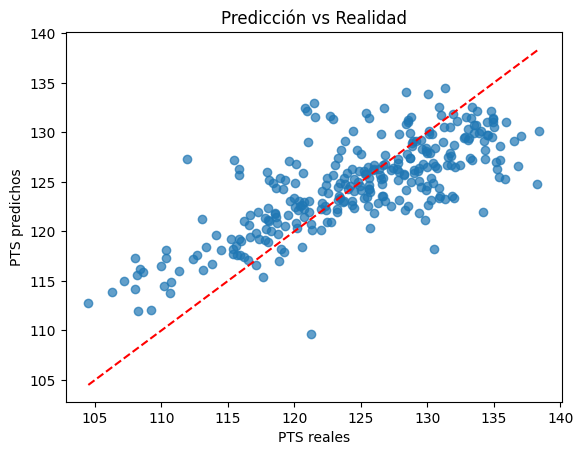

In [4]:
# Selección de variables 
X = df.drop(columns=["SSPL"])
y = df["SSPL"]

# División en conjunto de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creación y entrenamiento del modelo
modelo_no_t_bl = LinearRegression()
modelo_no_t_bl.fit(X_train, y_train)

# Predicciones
y_pred = modelo_no_t_bl.predict(X_test)

# Evaluación del modelo
coeficientes = pd.Series(modelo_no_t_bl.coef_, index=X_train.columns)
print("Intercepto:", modelo_no_t_bl.intercept_)
print("\nCoeficientes:")
print(coeficientes)

# Cálculo de error cuadrátrico y R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("----------------------------------------------------")
print("MSE:", mse)
print("R²:", r2)
print("----------------------------------------------------")

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("PTS reales")
plt.ylabel("PTS predichos")
plt.title("Predicción vs Realidad")
plt.show()

# 4. FUCO

A través de este apartado, se realiza la implementación de FUCO. Para ello, en primer lugar, se realiza la división del espacio de respuesta a partir del la observación fáctica seleccionada y los umbrales de epsilon y delta definidos. Posteriormente, se realiza la generación de las alteración de la observación que en este caso serán mediante **Permutación y guiado**. Estas alteraciónes de la observación será evaluadas mediante diferentes propiedades para comprobar cuales de ellas son las mejores para construir explicaciones contrafácticas. Por último, se realizará la construcción de las explicaciones.

## 4.1 División del espacio de respuesta

Como primer paso se realiza la divisón del espacio de respuesta. Para ello, es necesario seleccionar una observación a analizar la cual en nuestro caso es la 1487. Posteriormente, se definen los umbrales y se realiza el filtrado del conjunto de datos para la construcción de los Response sets:

In [5]:
# Se calcula las predicciones del modelo para los regisros
df['SSPL_pred'] = modelo_no_t_bl.predict(X)

# Se selecciona el resgistro objetivo sobre el que se calcularan los contrafácticos
print("----------- OBSERVACIÓN ORIGINAL -----------")
pred_obj = 123.514
print(df[df['SSPL']==pred_obj])

# Se definen los umbrales de epsilon y delta que dividiran el espacio de respuesta
epsilon_u_y = pred_obj + 2 
epsilon_l_y = pred_obj - 2 
delta_u_y = pred_obj + 6 
delta_l_y = pred_obj - 6 

# Se divide el espacio de respuesta y se construyen los Response sets
df_RF = df[(df['SSPL_pred'] <=epsilon_u_y) & (df['SSPL_pred'] >= epsilon_l_y)].reset_index().drop('index',axis=1) 
df_RCF = df[((df['SSPL_pred'] >=epsilon_u_y) & (df['SSPL_pred'] <= delta_u_y)) | ((df['SSPL_pred'] <=epsilon_l_y) & (df['SSPL_pred'] >= delta_l_y))].reset_index().drop('index',axis=1)
df_FCF = df[(df['SSPL_pred'] >=epsilon_u_y) | (df['SSPL_pred'] <= epsilon_l_y)].reset_index().drop('index',axis=1) 

----------- OBSERVACIÓN ORIGINAL -----------
        f  alpha       c  U_infinity     delta     SSPL   SSPL_pred
1487  200   15.6  0.1016        39.6  0.052849  123.514  118.958208


Se realiza la visualización de la división del espacio de respuesta:

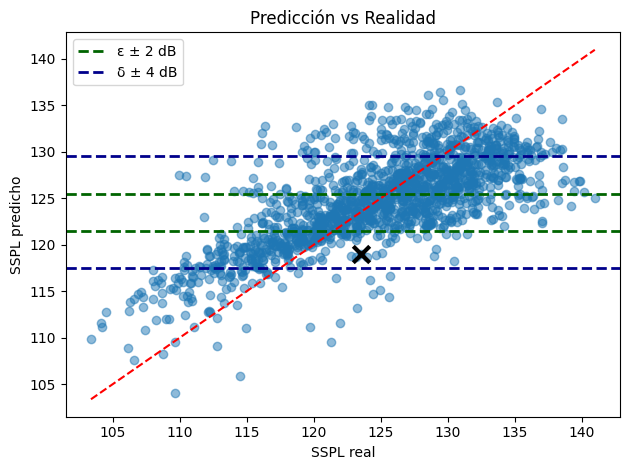

In [6]:
y_test = df['SSPL']
y_pred = df['SSPL_pred']

# Asume que ya tienes: y_test (Series), y_pred (array-like), pred_obj (float)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
y_pred_arr = np.asarray(y_pred)
i = df[df['SSPL']==pred_obj].index[0]

x_obj = y_test.iloc[i]      # SSPL real correspondiente
y_obj = y_pred_arr[i]       # SSPL predicho (cerca de pred_obj)

plt.scatter([x_obj], [y_obj], marker="x", s=140, linewidths=3, color = 'black')

# Colores distintos
epsilon_color = "darkgreen"
delta_color   = "darkblue"

plt.axhline(y=epsilon_u_y, linestyle="--", linewidth=2, color=epsilon_color, label="ε ± 2 dB")
plt.axhline(y=epsilon_l_y, linestyle="--", linewidth=2, color=epsilon_color)

plt.axhline(y=delta_u_y, linestyle="--", linewidth=2, color=delta_color, label="δ ± 4 dB")
plt.axhline(y=delta_l_y, linestyle="--", linewidth=2, color=delta_color)

plt.xlabel("SSPL real")
plt.ylabel("SSPL predicho")
plt.title("Predicción vs Realidad")
plt.legend()
plt.tight_layout()
plt.show()


## 4.2 Generación de observaciones candidatas

Para la generación de las observaciones candidatas, en este caso se ha seleccionado el método de *Permuación y guiado*. A través de este, se pueden obtener alteraciones de la observación a partir de la modificación controlada de los valores de la observación original.

Adicionalmente en esta sección, se realiza la construcción de las métricas de evaluación. En nuestro caso para FUCO han sido selecciónadas la validez, la proximidad, la robustez y la plausbilidad. Con estas variables se puede conocer a las alteraciones de la observación desde diferentes puntos de vista.

### 4.2.1 Generación de observaciones

Se realiza la generación de observaciones mediante el método seleccionado:

In [7]:
# 1º CREACIÓN DE OBSERVACIONES: Se generan las observaciones alteradas a partir de la observación factual
# Instancia factual:
df_factual = df[df['SSPL']==pred_obj].copy()
print("----------- OBSERVACIÓN FACTICA -----------")
print(df_factual)

# Extracción de valores de variables para la creación de observaciones
f = df_factual['f'].iloc[0]
alpha = df_factual['alpha'].iloc[0]
c = df_factual['c'].iloc[0]
u_infinity = df_factual['U_infinity'].iloc[0]
delta = df_factual['delta'].iloc[0]
sspl = df_factual['SSPL'].iloc[0]

# Valores únicos disponibles (restricciones)
f_values = df['f'].unique()
c_values = df['c'].unique()
u_values = df['U_infinity'].unique()

# Número de muestras a generar
n_samples = 1000

# Generación de observaciones a evaluar
np.random.seed(42)
df_obs_pg  = pd.DataFrame({
    'f': np.random.choice(f_values, n_samples),
    'alpha': alpha + np.random.uniform(-2.0, 2.0, n_samples),  # Perturbación controlada
    'c': np.random.choice(c_values, n_samples),
    'U_infinity': np.random.choice(u_values, n_samples),
    'delta': delta + np.random.uniform(-0.002, 0.002, n_samples)  # Perturbación controlada
})

# Obtención de valores a predecir
df_obs_pg['SSPL_pred'] = modelo_no_t_bl.predict(df_obs_pg)

# 2º SELECCIÓN DE RCF: Se seleccionan las observaciones generadas dentro de los RCF
df_obs_pg = df_obs_pg[((df_obs_pg['SSPL_pred'] >=epsilon_u_y) & (df_obs_pg['SSPL_pred'] <= delta_u_y)) | ((df_obs_pg['SSPL_pred'] <=epsilon_l_y) & (df_obs_pg['SSPL_pred'] >= delta_l_y))].reset_index().drop('index',axis=1)

----------- OBSERVACIÓN FACTICA -----------
        f  alpha       c  U_infinity     delta     SSPL   SSPL_pred
1487  200   15.6  0.1016        39.6  0.052849  123.514  118.958208


### 4.2.2 Evaluación de observaciones

Se realiza la construcción de las métricas de evaluación

In [8]:
# Se genera el tablón de evaluación
df_tablon_eval_pg = pd.DataFrame(index=df_obs_pg.index,columns=['validez','accionabilidad','accionabilidad_restricciones','plausibilidad_knn','robustez','proximidad_L1'])

#### 4.2.2.1 VALIDEZ

In [9]:
df_tablon_eval_pg['validez'] = True

#### 4.2.2.2 ACCIONABILIDAD

In [10]:
# Variables para evaluación
accionables = ['f', 'alpha', 'c', 'U_infinity', 'delta']
todas_las_vars = df_obs_pg.columns.drop('SSPL_pred')
inmutables = list(set(todas_las_vars) - set(accionables))

# Evaluar número de variables que cambiaron
df_tablon_eval_pg['accionabilidad'] = df_obs_pg[accionables].apply(
    lambda row: sum(row[col] != df_factual.iloc[0][col] for col in accionables),
    axis=1
)

# Evaluar cumplimiento de restricciones
cols_inmutables = [col for col in df_obs_pg.columns if col not in accionables + ['SSPL_pred']]

if cols_inmutables:
    df_tablon_eval_pg['accionabilidad_restricciones'] = df_obs_pg[cols_inmutables].apply(
        lambda row: all(row[col] == df_factual.iloc[0][col] for col in cols_inmutables),
        axis=1
    )
else:
    df_tablon_eval_pg['accionabilidad_restricciones'] = True

#### 4.2.2.3 PLAUSIBIDAD

In [11]:
# Variables de entrada para plausibilidad (excluyendo SSPL)
real_data = df_RCF.drop(columns=['SSPL','SSPL_pred'])
X_cf = df_obs_pg.drop(columns=['SSPL_pred'])

# Ajustar modelo KNN con datos reales
k = 2
knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(real_data)

# Calcular distancias promedio a los k vecinos más cercanos
distances, _ = knn.kneighbors(X_cf)
df_tablon_eval_pg['plausibilidad_knn'] = distances.mean(axis=1).round(2)

#### 4.2.2.4 ROBUSTEZ

In [12]:
# Función de robustez mejorada
def estimate_robustness(row, model, n_perturb=5, noise=0.01):
    X = row.copy()
    perturbations = pd.DataFrame([
        X + np.random.normal(0, noise, size=X.shape)
        for _ in range(n_perturb)
    ], columns=X.index)
    preds = model.predict(perturbations)
    return np.std(preds)

# Seleccionar solo columnas de entrada (excluye predicción y metadatos)
cols_entrada = [col for col in df_obs_pg.columns if col not in ['SSPL_pred']]

# Aplicar sobre las observaciones y almacenar en el tablón
df_tablon_eval_pg['robustez'] = df_obs_pg[cols_entrada].apply(lambda row: estimate_robustness(row, modelo_no_t_bl), axis=1).round(2)

#### 4.2.2.5 PROXIMIDAD

In [13]:
# Proximidad L1 respecto al factual
x_factual_vector = df_factual[accionables].iloc[0].values
df_tablon_eval_pg['proximidad_L1'] = df_obs_pg[accionables].apply(
    lambda row: norm(row.values - x_factual_vector, ord=1), axis=1).round(2)

## 4.3 Analisis de resultados de la evaluación

Para seleccionar los mejores contrafácticos, se realiza la utilización de un Frente de Pareto que es una estructura que permite la evaluación multiobjetivo. En nuestro caso, utilizaremos el frente de Pareto la ordenación de las métricas de evaluación según su proximidad, plausibidad y robustez de manera descendente. Con esto los contrafácticos serán seleccionados mediante la proximidad en primer lugar, la plausibidad en segundo y la robustez finalmente. Se realiza la construcción del frente:

In [14]:
df_pareto = df_tablon_eval_pg[['plausibilidad_knn', 'robustez', 'proximidad_L1']]
df_pareto.head()

,plausibilidad_knn,robustez,proximidad_L1
0,1.55,0.54,2950.92
1,1.01,1.14,216.41
2,1.38,0.63,801.78
3,1.48,1.48,462.42
4,1.56,0.69,332.51


### 4.3.1 Resumen estadístico general

Se extraen de cada una las propiedades del frente estadísticas para su comparación con otros métodos:

In [15]:
print("----------- VOLUMETRÍA -----------")
print(df_pareto.shape)

print("\n----------- MEDIAS -----------")
print(df_pareto.mean())

print("\n----------- DESVIACION -----------")
print(df_pareto.std())

----------- VOLUMETRÍA -----------
(277, 3)

----------- MEDIAS -----------
plausibilidad_knn       2.937906
robustez                1.157437
proximidad_L1        1074.536209
dtype: float64

----------- DESVIACION -----------
plausibilidad_knn       2.094773
robustez                0.427374
proximidad_L1        1085.045424
dtype: float64


### 4.3.2 Ordenación del frente de pareto

Se realiza la ordenación del frente de pareto:

In [16]:
df_pareto_sorted = df_pareto.sort_values(
    by=["proximidad_L1", "plausibilidad_knn", "robustez"],
    ascending=[True, True, True]
)

df_pareto_sorted.head(10)

,plausibilidad_knn,robustez,proximidad_L1
51,1.01,0.62,0.15
73,1.14,1.51,0.24
252,0.90,0.83,0.48
46,0.90,1.63,0.49
234,0.90,1.28,0.54
100,0.90,0.85,0.99
208,1.50,1.12,1.07
220,0.90,1.23,1.23
142,0.95,0.74,1.81
119,1.50,1.11,1.82


## 4.4 Generación de explicaciones

Para finalizar se realiza la generación de explicación. Para nuestro caso seleccionaremos las 5 alteraciones de la observación ordenadas anterirometne y se construirá una explicación con ellas en formato texto garantizando el traslado de conocimiento al usuario que lo lea:

In [17]:
# 1) Selección de la observación factual (si hay varias, toma la primera)
x_factual = df_factual.iloc[0]

try:
    y_factual = float(modelo_no_t_bl.predict(pd.DataFrame([x_factual[accionables].values], columns=accionables))[0])
except Exception:
    y_factual = None

# 2) Seleccionar las 5 mejores observaciones del frente ordenado
top5_idx = df_pareto_sorted.head(5).index
top5_obs = df_obs_pg.loc[top5_idx].copy()              # observaciones completas (incluye variables)
top5_metrics = df_pareto_sorted.loc[top5_idx].copy()   # métricas (prox, plaus, robust)

# 3) Función para construir explicación en texto
def generar_explicacion_cf(x_fact, x_cf_row, metrics_row, variables, y_fact=None, model=None, dec=4):
    cambios = []

    for v in variables:
        if v not in x_cf_row.index or v not in x_fact.index:
            continue

        a = x_fact[v]
        b = x_cf_row[v]

        # Evitar "cambios" por redondeo en floats
        if isinstance(a, (float, np.floating)) or isinstance(b, (float, np.floating)):
            if abs(float(a) - float(b)) < 10**(-dec):
                continue

        # Formateo bonito
        a_fmt = f"{float(a):.{dec}f}" if isinstance(a, (float, np.floating)) else str(a)
        b_fmt = f"{float(b):.{dec}f}" if isinstance(b, (float, np.floating)) else str(b)

        cambios.append(f"- {v}: {a_fmt} → {b_fmt}")

    if len(cambios) == 0:
        cambios_txt = "No se detectan cambios en las variables consideradas."
    else:
        cambios_txt = "\n".join(cambios)

    # Métricas
    prox = metrics_row.get("proximidad_L1", None)
    plaus = metrics_row.get("plausibilidad_knn", None)
    rob = metrics_row.get("robustez", None)

    met_txt = []
    if prox is not None: met_txt.append(f"proximidad={prox:.2f}")
    if plaus is not None: met_txt.append(f"plausibilidad={plaus:.2f}")
    if rob is not None: met_txt.append(f"robustez={rob:.2f}")
    met_txt = ", ".join(met_txt)

    # (Opcional) predicción del CF
    y_cf = None
    if model is not None:
        try:
            y_cf = float(model.predict(pd.DataFrame([x_cf_row[variables].values], columns=variables))[0])
        except Exception:
            y_cf = None

    # Texto final
    header = f"Explicación contrafáctica ({met_txt})" if met_txt else "Explicación contrafáctica"
    pred_txt = ""
    if (y_fact is not None) and (y_cf is not None):
        pred_txt = f"\nPredicción: {y_fact:.4f} → {y_cf:.4f}"

    texto = (
        f"{header}\n"
        f"Si modificas la observación original aplicando los siguientes cambios, "
        f"la observación se desplaza a una región contrafactual válida (RCF):\n"
        f"{cambios_txt}"
        f"{pred_txt}\n"
    )
    return texto

# 4) Generar el texto con las 5 explicaciones
explicaciones = []
for i, idx in enumerate(top5_idx, start=1):
    texto_i = generar_explicacion_cf(
        x_fact=x_factual,
        x_cf_row=top5_obs.loc[idx],
        metrics_row=top5_metrics.loc[idx],
        variables=accionables,
        y_fact=y_factual,
        model=modelo_no_t_bl,
        dec=4
    )
    explicaciones.append(f"CF #{i}\n{texto_i}")

explicaciones_texto = "\n" + ("-" * 60) + "\n"
explicaciones_texto = explicaciones_texto.join(explicaciones)

print(explicaciones_texto)

CF #1
Explicación contrafáctica (proximidad=0.15, plausibilidad=1.01, robustez=0.62)
Si modificas la observación original aplicando los siguientes cambios, la observación se desplaza a una región contrafactual válida (RCF):
- alpha: 15.6000 → 15.4969
- c: 0.1016 → 0.0508
- delta: 0.0528 → 0.0523
Predicción: 118.9582 → 120.8230

------------------------------------------------------------
CF #2
Explicación contrafáctica (proximidad=0.24, plausibilidad=1.14, robustez=1.51)
Si modificas la observación original aplicando los siguientes cambios, la observación se desplaza a una región contrafactual válida (RCF):
- alpha: 15.6000 → 15.3641
Predicción: 118.9582 → 119.0507

------------------------------------------------------------
CF #3
Explicación contrafáctica (proximidad=0.48, plausibilidad=0.90, robustez=0.83)
Si modificas la observación original aplicando los siguientes cambios, la observación se desplaza a una región contrafactual válida (RCF):
- alpha: 15.6000 → 16.0255
- c: 0.1016 →